In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Import Datasets
df = pd.read_csv("data.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
#Checking null values
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [5]:
df.describe()


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


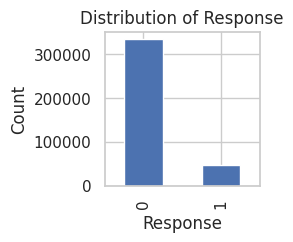

In [6]:
value_counts=df['Response'].value_counts()
plt.figure(figsize=(2,2))
value_counts.plot(kind='bar')
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Response')
plt.show()

<Axes: >

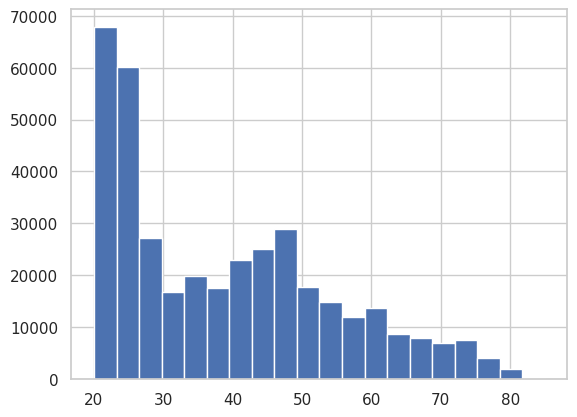

In [7]:
#For age
df['Age'].hist(bins=20)

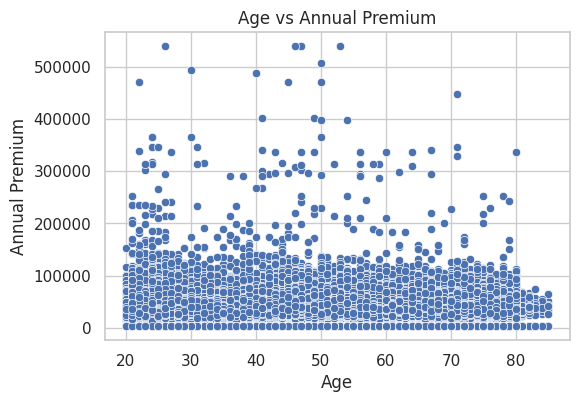

In [8]:
#Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age',y='Annual_Premium', data=df)
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.title('Age vs Annual Premium')
plt.show()

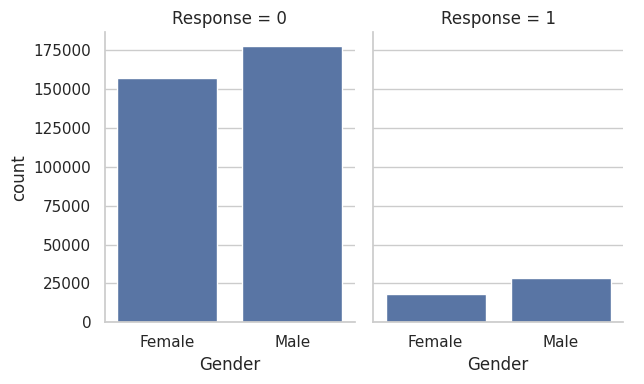

In [9]:
data = df.groupby(['Gender','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()

g= sns.catplot(x='Gender',y='count',col='Response',data=data, kind='bar', height=4, aspect=.8)

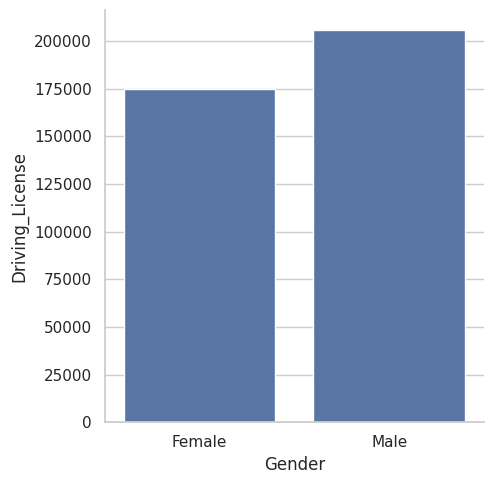

In [10]:
#Driving license by gender
data = df.groupby(['Gender'])['Driving_License'].count().to_frame().reset_index()
# data 
sns.catplot(x='Gender',y='Driving_License',data=data,kind='bar')

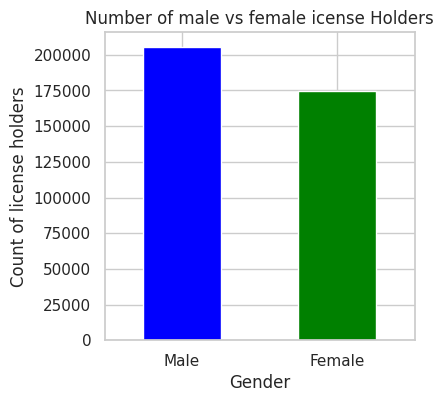

In [11]:
#filter for only license holder(driving_License==1)
license_holders = df[df['Driving_License']==1]
gender_counts = license_holders['Gender'].value_counts()

#plotting
plt.figure(figsize=(4,4))
gender_counts.plot(kind='bar',color=['blue','green'])
plt.title('Number of male vs female icense Holders')
plt.xlabel('Gender')
plt.ylabel('Count of license holders')
plt.xticks(rotation=0)
plt.show()

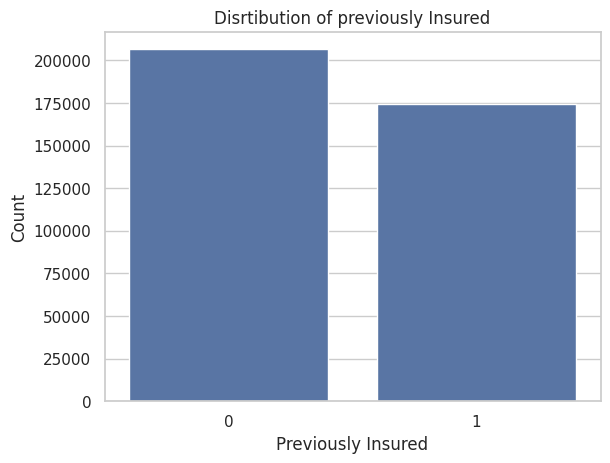

In [12]:
#customer with existing insurance
sns.countplot(x='Previously_Insured', data =df)
plt.title('Disrtibution of previously Insured')
plt.xlabel('Previously Insured')
plt.ylabel('Count')
plt.show()


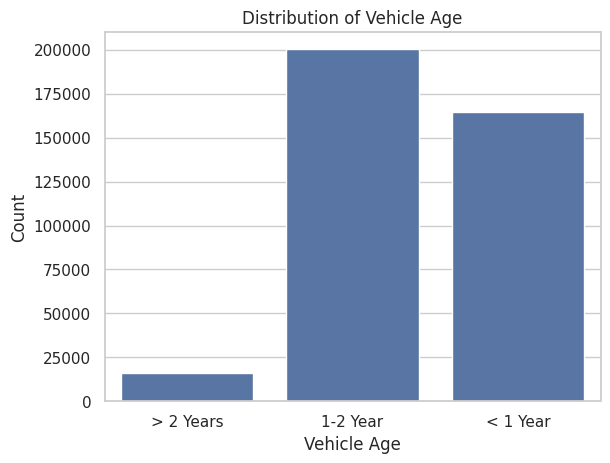

In [13]:
#checking vechicle age dist
sns.countplot(x='Vehicle_Age',data=df)
plt.title('Distribution of Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.show()

In [14]:
#Response vs vehicle age
data =df.groupby(['Vehicle_Age','Response'])['id'].count().to_frame().rename(columns={'id':'count'})
data.reset_index()

,Vehicle_Age,Response,count
0,1-2 Year,0,165510
1,1-2 Year,1,34806
2,< 1 Year,0,157584
3,< 1 Year,1,7202
4,> 2 Years,0,11305
5,> 2 Years,1,4702


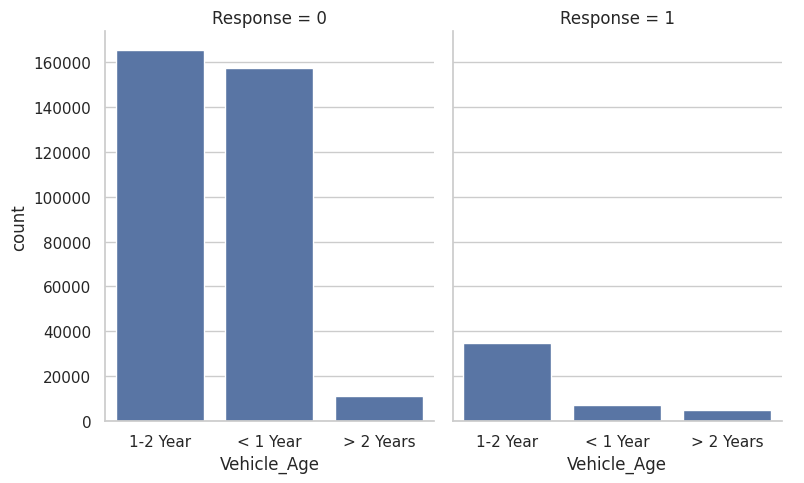

In [15]:
a = sns.catplot(x='Vehicle_Age',y='count', col='Response',data= data,kind='bar',
                height=5,aspect=.8)

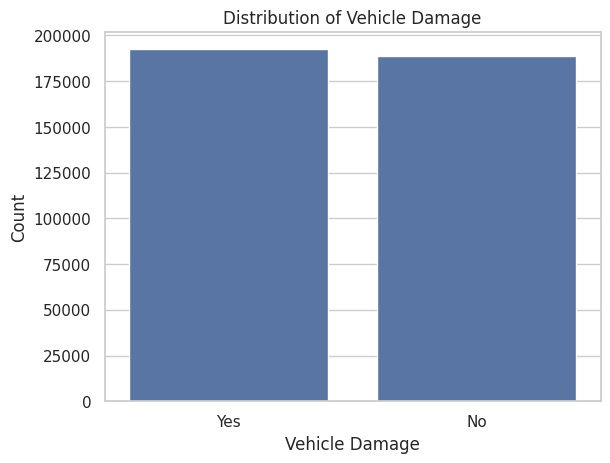

In [16]:
#dist for Vehicle_Damage col
sns.countplot(x='Vehicle_Damage',data= df)
plt.title('Distribution of Vehicle Damage')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
plt.show()


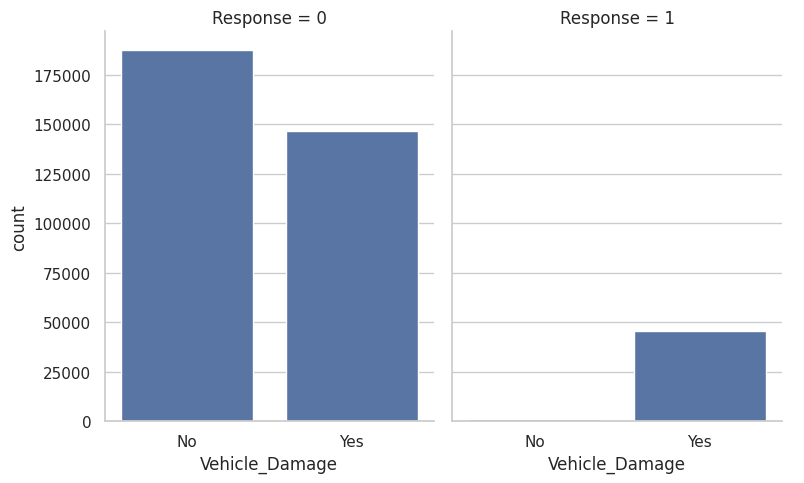

In [17]:
data = df.groupby(['Vehicle_Damage','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
sns.catplot(x='Vehicle_Damage',y='count',col='Response',data= data, kind='bar', height=5, aspect=.8)

In [18]:
#Checking stars for annual premium
df.Annual_Premium.describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

### Data Preprocessing

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [20]:
num_feat = ['Age','Vintage']   
cat_feat = ['Gender','Driving_License','Previously_Insured','Vehicle_Age_It_1_Year','Vehicle_Age_gt_2_Year','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [21]:
#mapping 'Gender' col to (0,1) values
df['Gender'] = df['Gender'].map({'Female':0,'Male':1}).astype(int)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [22]:
for col in df.columns:
    print(f'{col} : {df[col].dtype}')

id : int64
Gender : int64
Age : int64
Driving_License : int64
Region_Code : float64
Previously_Insured : int64
Vehicle_Age : object
Vehicle_Damage : object
Annual_Premium : float64
Policy_Sales_Channel : float64
Vintage : int64
Response : int64


In [23]:
#Creating dummpy cols for categorical features
df = pd.get_dummies(df,drop_first=True)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [24]:
for col in df.columns:
    print(f'{col} : {df[col].dtype}')

id : int64
Gender : int64
Age : int64
Driving_License : int64
Region_Code : float64
Previously_Insured : int64
Annual_Premium : float64
Policy_Sales_Channel : float64
Vintage : int64
Response : int64
Vehicle_Age_< 1 Year : bool
Vehicle_Age_> 2 Years : bool
Vehicle_Damage_Yes : bool


In [25]:
#cols renaming and keeping dtypes as int
df= df.rename(columns={'Vehicle_Age_< 1 Year': 'Vehicle_Age_It_1_Year','Vehicle_Age_> 2 Years':'Vehicle_Age_gt_2_Year'})
df['Vehicle_Age_It_1_Year'] = df['Vehicle_Age_It_1_Year'].astype('int')
df['Vehicle_Age_gt_2_Year'] = df['Vehicle_Age_gt_2_Year'].astype('int')
df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype('int')

for column in cat_feat:
    df[column]= df[column].astype('str')

In [27]:
#Scaling the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler

ss = StandardScaler()
df[num_feat]= ss.fit_transform(df[num_feat])

mm = MinMaxScaler()
df[['Annual_Premium']] = mm. fit_transform(df[['Annual_Premium']])

# Deopping id col
id = df.id
df =df.drop('id',axis=1)


In [29]:
#train test split
from sklearn.model_selection import train_test_split

train_target = df['Response']
train = df.drop(['Response'],axis=1)
X_train,X_test,y_train,y_test = train_test_split(train,train_target,random_state=7,stratify=train_target)


In [30]:
train_target

0         1
1         0
2         1
3         0
4         0
         ..
381104    0
381105    0
381106    0
381107    0
381108    0
Name: Response, Length: 381109, dtype: int64

In [31]:
train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age_It_1_Year,Vehicle_Age_gt_2_Year,Vehicle_Damage_Yes
0,1,0.333777,1,28.0,0,0.070366,26.0,0.748795,0,1,1
1,1,2.396751,1,3.0,0,0.057496,26.0,0.342443,0,0,0
2,1,0.527181,1,28.0,0,0.066347,26.0,-1.521998,0,1,1
3,1,-1.148985,1,11.0,1,0.048348,152.0,0.581474,1,0,0
4,0,-0.633242,1,41.0,1,0.046259,152.0,-1.378580,1,0,0


### MODEL TRAINER

In [33]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

random_search = {'criterion': ['entropy','gini'],
                 'max_depth':[2,3,5,7,10],
                 'min_samples_leaf':[4,6,8],
                 'min_samples_split': [5,7,10],
                 'n_estimators':[300]}

clf = RandomForestClassifier()
model = RandomizedSearchCV(estimator=clf,param_distributions=random_search,n_iter=10,
                           cv=4,verbose=1,random_state=7,n_jobs=-1)
model.fit(X_train,y_train)


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['entropy', 'gini'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [4, 6, ...], 'min_samples_split': [5, 7, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,7
,error_score,nan


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

my_params = {
    'n_estimators':[300],
    'min_samples_split' :[7],
    'min_samples_leaf': [4],
    'max_depth':[10],
    'criterion':['entropy']
}

clf = RandomForestClassifier()
model =RandomizedSearchCV(estimator=clf,param_distributions=my_params,n_iter=10,cv=4,verbose=1,random_state=7,n_jobs=-1)

model.fit(X_train,y_train)

Fitting 4 folds for each of 1 candidates, totalling 4 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['entropy'], 'max_depth': [10], 'min_samples_leaf': [4], 'min_samples_split': [7], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,7
,error_score,nan


In [40]:
best_params = model.best_params_
print('BEst Hyperparameters:')
print(best_params)

BEst Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'entropy'}


In [41]:
#Save model
import pickle
filename = 'rf_model.pkl'
pickle.dump(model,open(filename,'wb'))

In [42]:
#loading back pickle file
rf_load = pickle.load(open(filename,'rb'))

### Model Evulation


In [44]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93     83600
           1       0.00      0.00      0.00     11678

    accuracy                           0.88     95278
   macro avg       0.44      0.50      0.47     95278
weighted avg       0.77      0.88      0.82     95278

